# 📺 Netflix Exploratory Data Analysis (EDA)

## 📌 Project Overview

This project performs an **Exploratory Data Analysis (EDA)** on the Netflix dataset to uncover meaningful insights and patterns in Netflix's content library.

The analysis explores:
- 🎬 Movies vs. TV Shows
- 📅 Content added over the years
- 🌍 Content distribution by country
- ⭐ Ratings and audience categories
- 🎭 Popular genres and categories
- ⏱️ Movie duration and TV show seasons
- 📈 Trends in Netflix content over time

The goal is to **clean, transform, analyze, and visualize the data** to understand how Netflix's content library has evolved and identify key trends using **Python, Pandas, Matplotlib, and Seaborn**.

## 🎯 Objective

To use data-driven analysis and visualization techniques to extract **actionable insights from Netflix's content catalog** and better understand its content distribution, growth, ratings, genres, and release trends.

In [1]:
#Importing all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from word cloud import WordCloud

In [2]:
df=pd.read_csv("netflix.csv")
df.head()
#any column having more than 50% unique values
#that column never contribute in project

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [4]:
df.rename(columns={'listed_in':'genre'},inplace=True)
df.columns
# Renaming the list in column to genres

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genre', 'description'],
      dtype='str')

In [5]:
df.drop(columns='show_id',inplace=True)  #--> Dropping the show_id column as it may be of no use in the analysis

In [6]:
df.duplicated().sum() #--> Checking for duplicates

np.int64(0)

In [7]:
df.isnull().sum() #--> Checking the missing values

type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
genre              0
description        0
dtype: int64

In [8]:
df.shape

(8807, 11)

In [9]:
df.dropna(subset=['date_added'],inplace=True)
df['date_added'].isna().sum()

np.int64(0)

In [10]:
df.dropna(subset=['rating'],inplace=True)
df['rating'].isna().sum()

np.int64(0)

In [11]:
df.dropna(subset=['duration'],inplace=True)
df['duration'].isna().sum()

np.int64(0)

In [12]:
df.isnull().sum()

type               0
title              0
director        2621
cast             825
country          829
date_added         0
release_year       0
rating             0
duration           0
genre              0
description        0
dtype: int64

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   type          8790 non-null   str  
 1   title         8790 non-null   str  
 2   director      6169 non-null   str  
 3   cast          7965 non-null   str  
 4   country       7961 non-null   str  
 5   date_added    8790 non-null   str  
 6   release_year  8790 non-null   int64
 7   rating        8790 non-null   str  
 8   duration      8790 non-null   str  
 9   genre         8790 non-null   str  
 10  description   8790 non-null   str  
dtypes: int64(1), str(10)
memory usage: 3.8 MB


In [14]:
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')
df['date_added'].isnull().sum()

np.int64(88)

In [15]:
df.dropna(subset=['date_added'],inplace=True)
df['date_added'].isna().sum()

np.int64(0)

In [16]:
df['day'] = df['date_added'].dt.day
df['month'] = df['date_added'].dt.month
df['year'] = df['date_added'].dt.year
df['month_name'] = df['date_added'].dt.month_name()
df['weekday'] = df['date_added'].dt.day_name()

df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday


In [17]:
df["duration"].unique()

<ArrowStringArray>
[   '90 min', '2 Seasons',  '1 Season',    '91 min',   '125 min', '9 Seasons',
   '104 min',   '127 min', '4 Seasons',    '67 min',
 ...
    '43 min',   '200 min',   '196 min',   '167 min',   '178 min',   '228 min',
    '18 min',   '205 min',   '201 min',   '191 min']
Length: 219, dtype: str

In [18]:
s1='179 min'
s1.split()[0]

'179'

In [19]:
s1='12 Seasons'
int(s1.split()[0])

12

In [20]:
df["duration"]=df["duration"].apply(lambda x:int(x.split()[0]))

In [21]:
df["duration"].unique()

array([ 90,   2,   1,  91, 125,   9, 104, 127,   4,  67,  94,   5, 161,
        61, 166, 147, 103,  97, 106, 111,   3, 110, 105,  96, 124, 116,
        98,  23, 115, 122,  99,  88, 100,   6, 102,  93,  95,  85,  83,
       113,  13, 182,  48, 145,  87,  92,  80, 117, 128, 119, 143, 114,
       118, 108,  63, 121, 142, 154, 120,  82, 109, 101,  86, 229,  76,
        89, 156, 112, 107, 129, 135, 136, 165, 150, 133,  70,  84, 140,
        78,   7,  64,  59, 139,  69, 148, 189, 141, 130, 138,  81, 132,
        10, 123,  65,  68,  66,  62,  74, 131,  39,  46,  38,   8,  17,
       126, 155, 159, 137,  12, 273,  36,  34,  77,  60,  49,  58,  72,
       204, 212,  25,  73,  29,  47,  32,  35,  71, 149,  33,  15,  54,
       224, 162,  37,  75,  79,  55, 158, 164, 173, 181, 185,  21,  24,
        51, 151,  42,  22, 134, 177,  52,  14,  53,  57,  28,  50,  26,
        45, 171,  27,  44, 146,  20, 157, 203,  41,  30, 194, 233, 237,
       230, 195, 253, 152, 190, 160, 208, 180, 144, 174, 170, 19

In [22]:
df['rating'].unique()

<ArrowStringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',       'NR',
 'TV-Y7-FV',       'UR']
Length: 14, dtype: str

### Netflix has officially categorised these into 3 main categories

- Replacing `TV-Y`, `TV-Y7`, `G`, `TV-G`, `PG`, `TV-PG`, `TV-Y7-FV` to **Kids**
- `PG-13`, `TV-14` to **Teens**
- `R`, `TV-MA`, `NC-17` to **Adults**
- `NR`, `UR` to **null values**

In [23]:
df['rating'] = df['rating'].replace(['TV-Y','TV-Y7','G','TV-G','PG','TV-PG','TV-Y7-FV'],'Kids')
df['rating'] = df['rating'].replace(['PG-13','TV-14'],'Teens')
df['rating'] = df['rating'].replace(['R','TV-MA','NC-17'],'Adults')
df['rating'] = df['rating'].replace(['NR','UR'],np.nan)
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,Adults,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,Adults,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday


In [24]:
df['rating'].unique()

<ArrowStringArray>
['Teens', 'Adults', 'Kids', nan]
Length: 4, dtype: str

In [25]:
df['rating'].isna().sum()

np.int64(81)

In [26]:
df.dropna(subset=['rating'],inplace=True)
df['rating'].isna().sum()

np.int64(0)

In [27]:
df.isna().sum()  

type               0
title              0
director        2535
cast             800
country          826
date_added         0
release_year       0
rating             0
duration           0
genre              0
description        0
day                0
month              0
year               0
month_name         0
weekday            0
dtype: int64

In [28]:
df[(df['director'].isna()) & (df['country'].isna()) & (df['cast'].isna())].shape[0]

96

In [29]:
df.shape

(8621, 16)

In [30]:
df.dropna(subset=['director','country','cast'], how = 'all',inplace=True)
df.shape

(8525, 16)

In [31]:
df.isna().sum()

type               0
title              0
director        2439
cast             704
country          730
date_added         0
release_year       0
rating             0
duration           0
genre              0
description        0
day                0
month              0
year               0
month_name         0
weekday            0
dtype: int64

In [32]:
df["cast"][2].split(",")

['Sami Bouajila',
 ' Tracy Gotoas',
 ' Samuel Jouy',
 ' Nabiha Akkari',
 ' Sofia Lesaffre',
 ' Salim Kechiouche',
 ' Noureddine Farihi',
 ' Geert Van Rampelberg',
 ' Bakary Diombera']

In [33]:
df_cast = pd.DataFrame(df['cast'].apply(lambda x: str(x).split(', ')).tolist(),index=df['title'])
df_cast

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
title,,,,,,,,,,,,,,,,,,,,,
Dick Johnson Is Dead,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood & Water,Ama Qamata,Khosi Ngema,Gail Mabalane,Thabang Molaba,Dillon Windvogel,Natasha Thahane,Arno Greeff,Xolile Tshabalala,Getmore Sithole,Cindy Mahlangu,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ganglands,Sami Bouajila,Tracy Gotoas,Samuel Jouy,Nabiha Akkari,Sofia Lesaffre,Salim Kechiouche,Noureddine Farihi,Geert Van Rampelberg,Bakary Diombera,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Kota Factory,Mayur More,Jitendra Kumar,Ranjan Raj,Alam Khan,Ahsaas Channa,Revathi Pillai,Urvi Singh,Arun Kumar,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Midnight Mass,Kate Siegel,Zach Gilford,Hamish Linklater,Henry Thomas,Kristin Lehman,Samantha Sloyan,Igby Rigney,Rahul Kohli,Annarah Cymone,Annabeth Gish,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zinzana,Ali Suliman,Saleh Bakri,Yasa,Ali Al-Jabri,Mansoor Alfeeli,Ahd,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zodiac,Mark Ruffalo,Jake Gyllenhaal,Robert Downey Jr.,Anthony Edwards,Brian Cox,Elias Koteas,Donal Logue,John Carroll Lynch,Dermot Mulroney,Chloë Sevigny,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zombieland,Jesse Eisenberg,Woody Harrelson,Emma Stone,Abigail Breslin,Amber Heard,Bill Murray,Derek Graf,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
df_cast = df_cast.stack()
df_cast

title                   
Dick Johnson Is Dead  0     nan
                      1     NaN
                      2     NaN
                      3     NaN
                      4     NaN
                           ... 
Zubaan                45    NaN
                      46    NaN
                      47    NaN
                      48    NaN
                      49    NaN
Length: 426250, dtype: str

In [35]:
df_cast = pd.DataFrame(df_cast)
df_cast

0
title                       
Dick Johnson Is Dead 0   nan
                     1   NaN
                     2   NaN
                     3   NaN
                     4   NaN
...                      ...
Zubaan               45  NaN
                     46  NaN
                     47  NaN
                     48  NaN
                     49  NaN

[426250 rows x 1 columns]

In [36]:
df_cast.reset_index(inplace=True)
df_cast

,title,level_1,0
0,Dick Johnson Is Dead,0,nan
1,Dick Johnson Is Dead,1,NaN
2,Dick Johnson Is Dead,2,NaN
3,Dick Johnson Is Dead,3,NaN
4,Dick Johnson Is Dead,4,NaN
...,...,...,...
426245,Zubaan,45,NaN
426246,Zubaan,46,NaN
426247,Zubaan,47,NaN
426248,Zubaan,48,NaN


In [37]:
df_cast = df_cast[['title',0]]
df_cast

,title,0
0,Dick Johnson Is Dead,nan
1,Dick Johnson Is Dead,NaN
2,Dick Johnson Is Dead,NaN
3,Dick Johnson Is Dead,NaN
4,Dick Johnson Is Dead,NaN
...,...,...
426245,Zubaan,NaN
426246,Zubaan,NaN
426247,Zubaan,NaN
426248,Zubaan,NaN


In [38]:
df_cast.columns=['title','cast']
df_cast

,title,cast
0,Dick Johnson Is Dead,nan
1,Dick Johnson Is Dead,NaN
2,Dick Johnson Is Dead,NaN
3,Dick Johnson Is Dead,NaN
4,Dick Johnson Is Dead,NaN
...,...,...
426245,Zubaan,NaN
426246,Zubaan,NaN
426247,Zubaan,NaN
426248,Zubaan,NaN


In [39]:
df_cast.replace('nan',np.nan,inplace=True)
df_cast.isna().sum()

title         0
cast     363310
dtype: int64

In [40]:
df_genre = pd.DataFrame(df['genre'].apply(lambda x: str(x).split(', ')).tolist(),index=df['title'])
df_genre = df_genre.stack()
df_genre = pd.DataFrame(df_genre)
df_genre.reset_index(inplace=True)
df_genre = df_genre[['title',0]]
df_genre.columns =['title','genre']
df_genre.replace('nan',np.nan,inplace=True)
df_genre.isna().sum()

title       0
genre    6818
dtype: int64

In [41]:
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genre', 'description', 'day',
       'month', 'year', 'month_name', 'weekday'],
      dtype='str')

In [42]:
df_director = pd.DataFrame(df['director'].apply(lambda x: str(x).split(', ')).tolist(),index=df['title'])
df_director = df_director.stack()
df_director = pd.DataFrame(df_director)
df_director.reset_index(inplace=True)
df_director = df_director[['title',0]]
df_director.columns =['title','director']
df_director.replace('nan',np.nan,inplace=True)
df_director.isna().sum()

title            0
director    103944
dtype: int64

In [43]:
df_country = pd.DataFrame(df['country'].apply(lambda x: str(x).split(', ')).tolist(),index=df['title'])
df_country = df_country.stack()
df_country = pd.DataFrame(df_country)
df_country.reset_index(inplace=True)
df_country = df_country[['title',0]]
df_country.columns =['title','country']
df_country.replace('nan',np.nan,inplace=True)
df_country.isna().sum()

title          0
country    92511
dtype: int64

In [44]:
df_cast.drop_duplicates(inplace=True)
df_genre.drop_duplicates(inplace=True)
df_director.drop_duplicates(inplace=True)
df_country.drop_duplicates(inplace=True)

In [45]:
df12=df_cast.merge(df_genre, on = 'title')
df12

,title,cast,genre
0,Dick Johnson Is Dead,NaN,Documentaries
1,Dick Johnson Is Dead,NaN,NaN
2,Blood & Water,Ama Qamata,International TV Shows
3,Blood & Water,Ama Qamata,TV Dramas
4,Blood & Water,Ama Qamata,TV Mysteries
...,...,...,...
201906,Zubaan,Chittaranjan Tripathy,International Movies
201907,Zubaan,Chittaranjan Tripathy,Music & Musicals
201908,Zubaan,NaN,Dramas
201909,Zubaan,NaN,International Movies


In [46]:
df123=df_director.merge(df12, on = 'title')
df123

,title,director,cast,genre
0,Dick Johnson Is Dead,Kirsten Johnson,NaN,Documentaries
1,Dick Johnson Is Dead,Kirsten Johnson,NaN,NaN
2,Dick Johnson Is Dead,NaN,NaN,Documentaries
3,Dick Johnson Is Dead,NaN,NaN,NaN
4,Blood & Water,NaN,Ama Qamata,International TV Shows
...,...,...,...,...
363722,Zubaan,NaN,Chittaranjan Tripathy,International Movies
363723,Zubaan,NaN,Chittaranjan Tripathy,Music & Musicals
363724,Zubaan,NaN,NaN,Dramas
363725,Zubaan,NaN,NaN,International Movies


In [47]:
df1234 = df_country.merge(df123, on = 'title')
df1234

,title,country,director,cast,genre
0,Dick Johnson Is Dead,United States,Kirsten Johnson,NaN,Documentaries
1,Dick Johnson Is Dead,United States,Kirsten Johnson,NaN,NaN
2,Dick Johnson Is Dead,United States,NaN,NaN,Documentaries
3,Dick Johnson Is Dead,United States,NaN,NaN,NaN
4,Dick Johnson Is Dead,NaN,Kirsten Johnson,NaN,Documentaries
...,...,...,...,...,...
801966,Zubaan,NaN,NaN,Chittaranjan Tripathy,International Movies
801967,Zubaan,NaN,NaN,Chittaranjan Tripathy,Music & Musicals
801968,Zubaan,NaN,NaN,NaN,Dramas
801969,Zubaan,NaN,NaN,NaN,International Movies


In [48]:
df_new = df.merge(df1234,on="title")
df_new

,type,title,director_x,cast_x,country_x,date_added,release_year,rating,duration,genre_x,description,day,month,year,month_name,weekday,country_y,director_y,cast_y,genre_y
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,NaN
2,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,NaN,NaN,Documentaries
3,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,NaN,NaN,NaN
4,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,NaN,Kirsten Johnson,NaN,Documentaries
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
801966,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,NaN,NaN,Chittaranjan Tripathy,International Movies
801967,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,NaN,NaN,Chittaranjan Tripathy,Music & Musicals
801968,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,NaN,NaN,NaN,Dramas
801969,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,NaN,NaN,NaN,International Movies


In [49]:
df_new.drop(columns = ['cast_x','country_x','director_x','genre_x'],inplace=True)
df_new

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country_y,director_y,cast_y,genre_y
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,NaN
2,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,NaN,NaN,Documentaries
3,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,NaN,NaN,NaN
4,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,NaN,Kirsten Johnson,NaN,Documentaries
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
801966,Movie,Zubaan,2019-03-02,2015,Teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,NaN,NaN,Chittaranjan Tripathy,International Movies
801967,Movie,Zubaan,2019-03-02,2015,Teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,NaN,NaN,Chittaranjan Tripathy,Music & Musicals
801968,Movie,Zubaan,2019-03-02,2015,Teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,NaN,NaN,NaN,Dramas
801969,Movie,Zubaan,2019-03-02,2015,Teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,NaN,NaN,NaN,International Movies


In [50]:
df_new.rename(columns={'country_y':'country','director_y':'director','cast_y':'cast','genre_y':'genre'},inplace=True)

In [51]:
df_new.head()


,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,NaN
2,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,NaN,NaN,Documentaries
3,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,NaN,NaN,NaN
4,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,NaN,Kirsten Johnson,NaN,Documentaries


In [52]:
df_new.shape

(801971, 16)

In [53]:
df_new['cast']=df_new['cast'].replace(np.nan,'Unknown')
df_new['country']=df_new['country'].replace(np.nan,'Unknown')
df_new['director']=df_new['director'].replace(np.nan,'Unknown')


In [54]:
df_new.head()

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,Unknown,Documentaries
1,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,Unknown,NaN
2,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Unknown,Unknown,Documentaries
3,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Unknown,Unknown,NaN
4,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,Unknown,Kirsten Johnson,Unknown,Documentaries


In [55]:
df_new.drop(["description"],axis=1,inplace=True)

In [56]:
df_new.duplicated().sum()

np.int64(0)

In [57]:
df_new.drop_duplicates(keep='first',inplace=True)

In [58]:
df_movies=df_new[df_new['type']=='Movie']
df_tvs=df_new[df_new['type']=='TV Show']


In [59]:
df_movies.shape

(663837, 15)

In [60]:
df_tvs.shape

(138134, 15)

In [61]:
df_tvs.rename(columns={'duration':'seasons'},inplace=True)

## 📊 Data Visualization

After completing the data cleaning and exploratory analysis, I started the **data visualization** phase to understand patterns, trends, and distributions in the Netflix dataset through different visualizations.

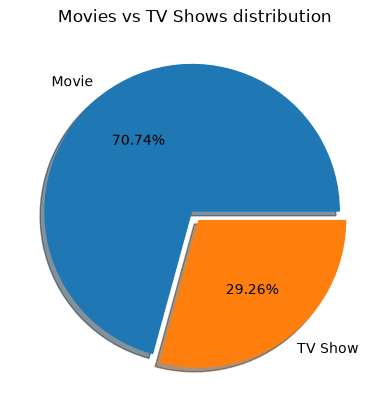

In [62]:
import matplotlib.pyplot as plt

plt.pie(df["type"].value_counts(), labels=df["type"].value_counts().index,
        autopct="%1.2f%%", explode=[0.03,0.04], shadow=True)

plt.title("Movies vs TV Shows distribution")
plt.show()

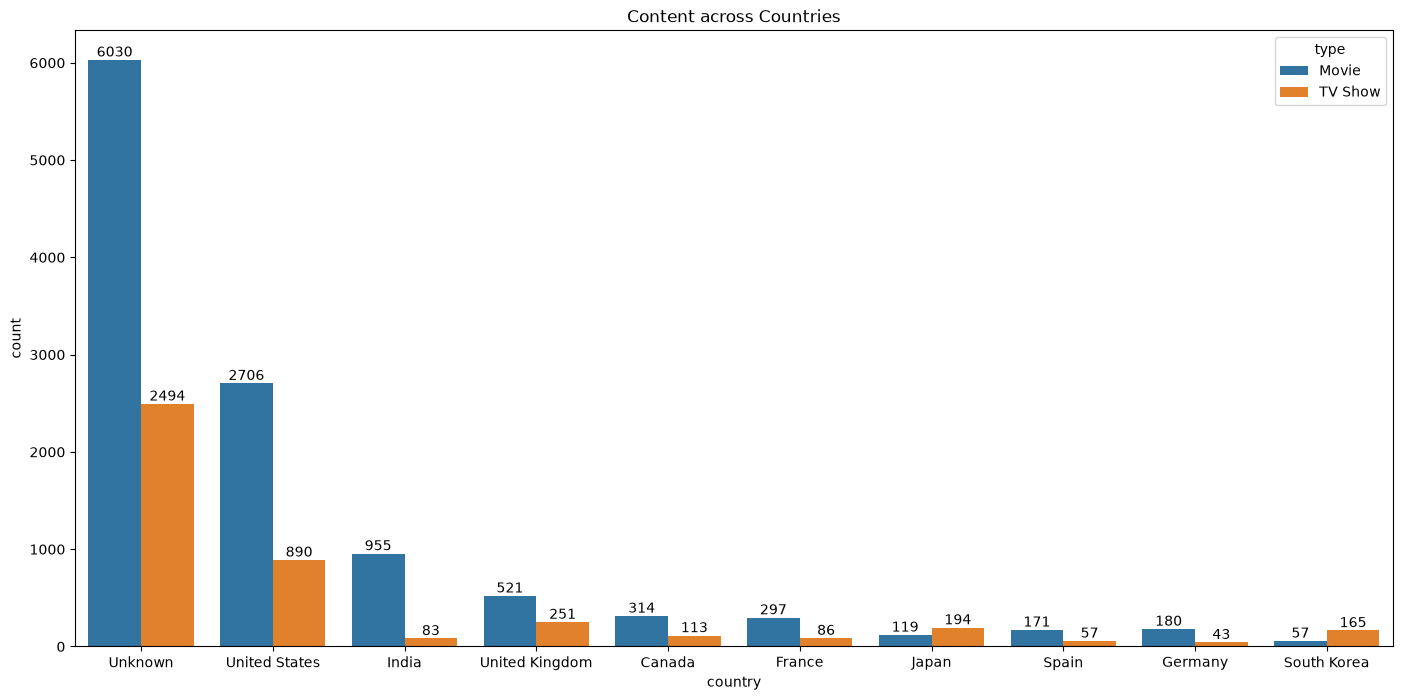

In [63]:
df_temp = df_new.drop_duplicates(subset=['country', 'title'])
df_temp

x = df_temp['country'].value_counts().head(10)
x

plt.figure(figsize=(17,8))
plt.title('Content across Countries')
label = sns.countplot(data=df_temp, x='country', hue='type', order=x.index)
for i in label.containers:
    label.bar_label(i)
plt.show()

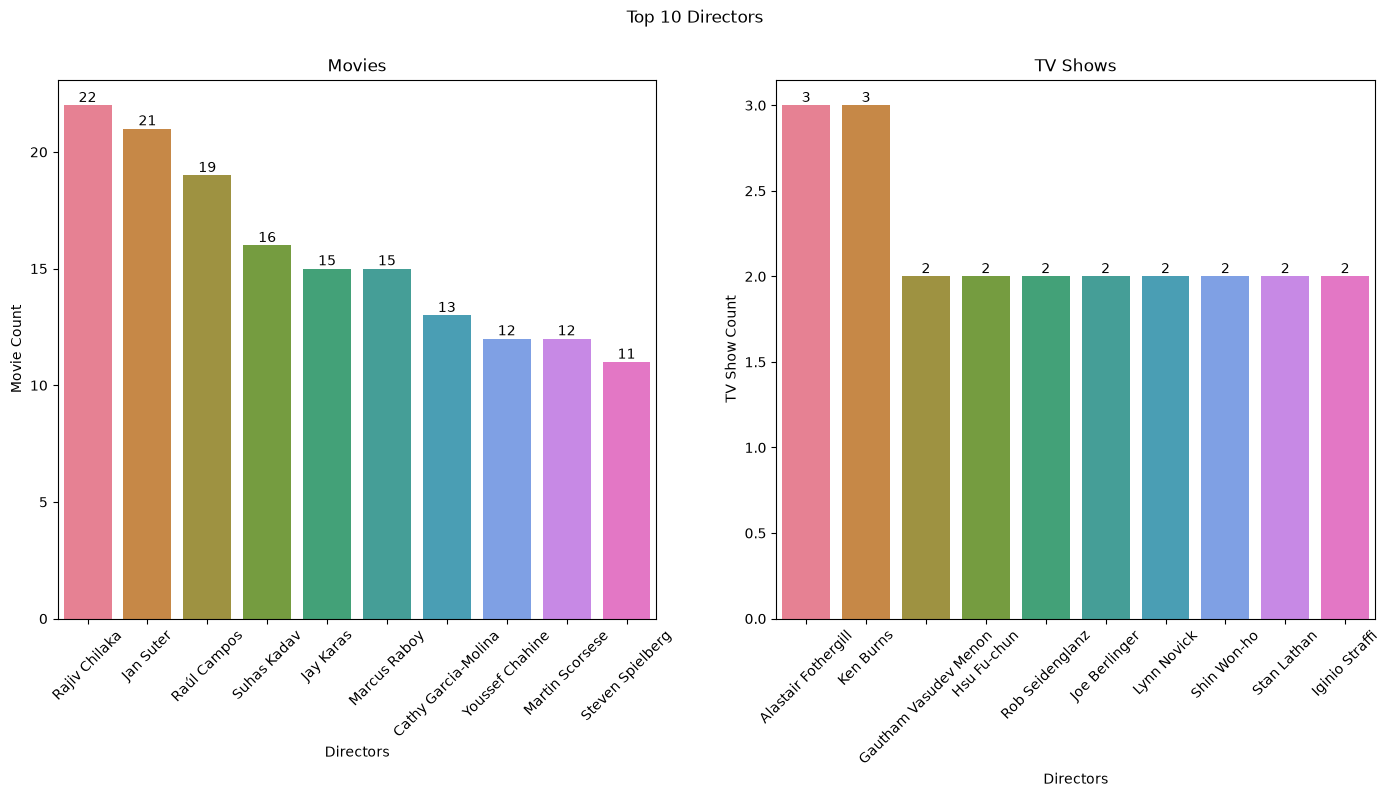

In [64]:
import warnings
warnings.filterwarnings('ignore')
df_movies_temp = df_movies.drop_duplicates(subset=['director', 'title'])
df_tv_temp = df_tvs.drop_duplicates(subset=['director', 'title'])

plt.figure(figsize=(17,7))
plt.suptitle('Top 10 Directors')

plt.subplot(1,2,1)
x = df_movies_temp['director'].value_counts()[1:11]
label = sns.countplot(data=df_movies_temp, x='director', order=x.index, palette='husl')
for i in label.containers:
    label.bar_label(i)
plt.title('Movies')
plt.xticks(rotation=45)
plt.xlabel('Directors')
plt.ylabel('Movie Count')

plt.subplot(1,2,2)

y = df_tv_temp['director'].value_counts()[1:11]

label = sns.countplot(data=df_tv_temp, x='director', order=y.index, palette='husl')

for i in label.containers:
    label.bar_label(i)

plt.title('TV Shows')
plt.xticks(rotation=45)
plt.xlabel('Directors')
plt.ylabel('TV Show Count')

plt.show()

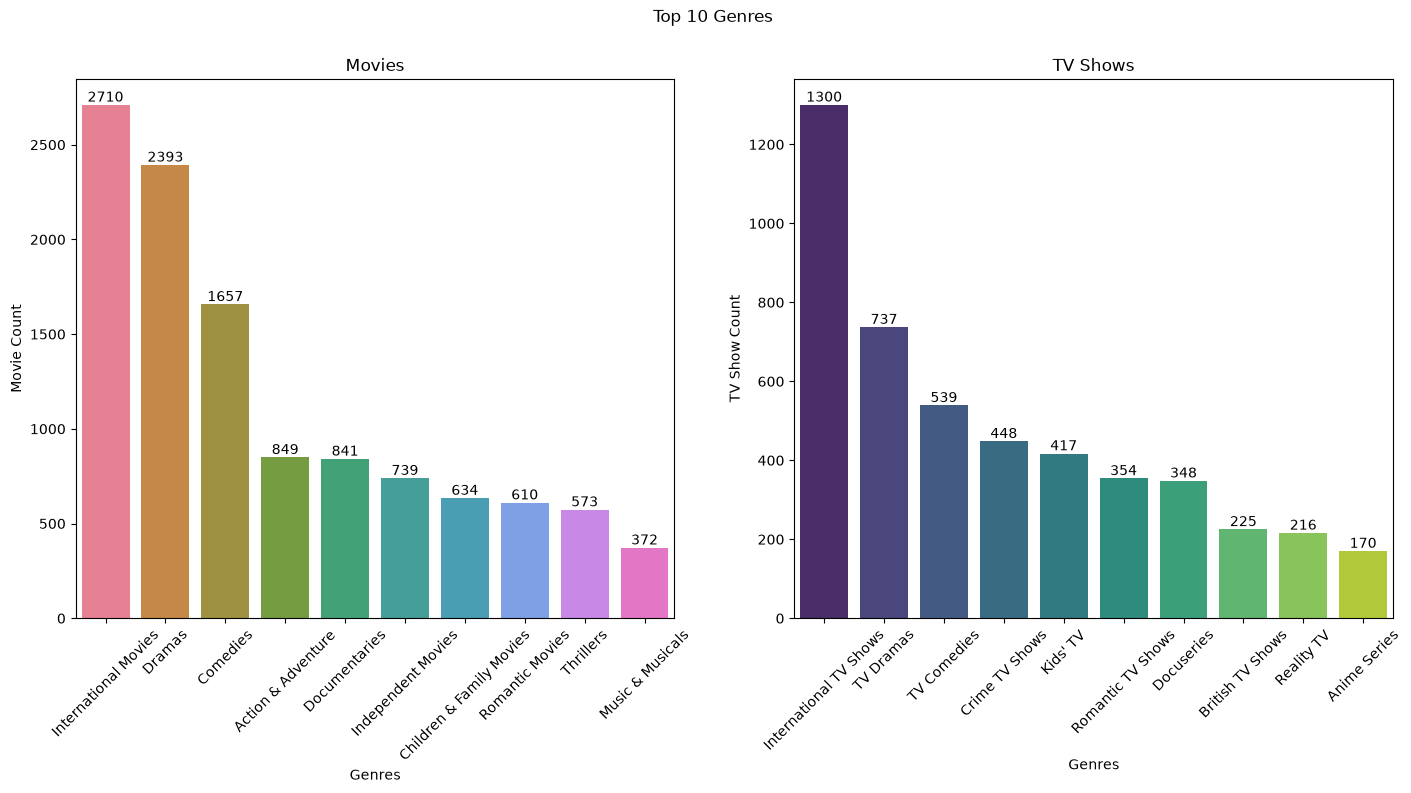

In [65]:
df_movies_temp = df_movies.drop_duplicates(subset=['genre', 'title'])
df_tvs_temp = df_tvs.drop_duplicates(subset=['genre', 'title'])

plt.figure(figsize=(17,7))
plt.suptitle('Top 10 Genres')

plt.subplot(1,2,1)
x = df_movies_temp['genre'].value_counts().head(10)
label = sns.countplot(data=df_movies_temp, x='genre', order=x.index, palette='husl')
for i in label.containers:
    label.bar_label(i)
plt.title('Movies')
plt.xticks(rotation=45)
plt.xlabel('Genres')
plt.ylabel('Movie Count')

plt.subplot(1,2,2)
y = df_tvs_temp['genre'].value_counts().head(10)
label = sns.countplot(data=df_tvs_temp, x='genre', order=y.index, palette='viridis')
for i in label.containers:
    label.bar_label(i)
plt.title('TV Shows')
plt.xticks(rotation=45)
plt.xlabel('Genres')
plt.ylabel('TV Show Count')

plt.show()

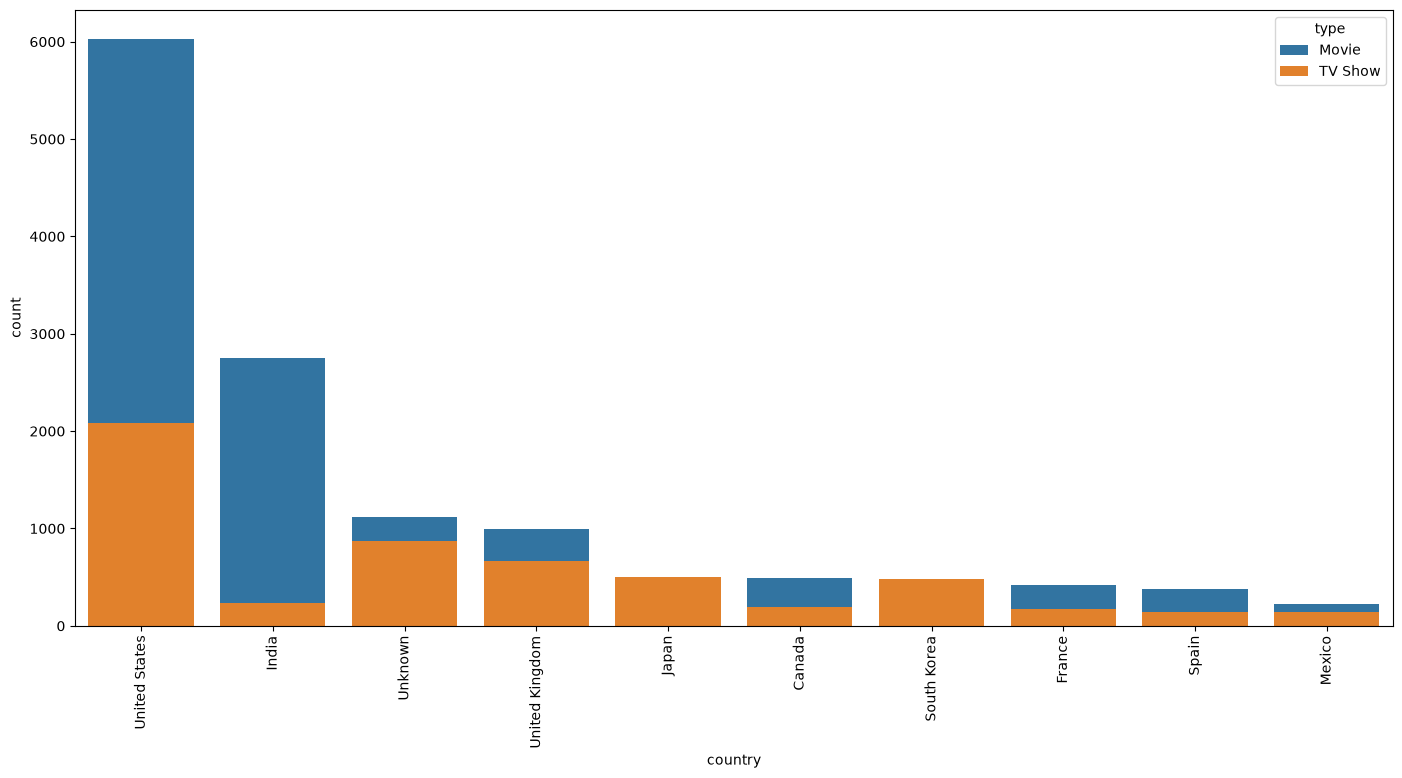

In [69]:
df_temp = df_new.drop_duplicates(subset=['genre', 'title'])

plt.figure(figsize=(17,8))
plt.xticks(rotation=90)

sns.countplot(
    data=df_temp,
    x='country',
    hue='type',
    dodge=False,
    order=df_temp['country'].value_counts().head(10).index
)

plt.show()

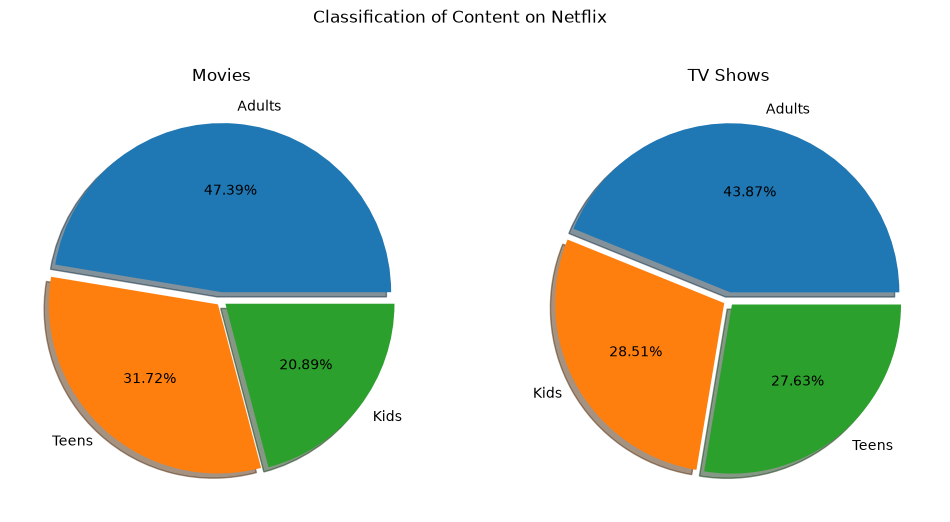

In [66]:
df_movies_temp = df_movies.drop_duplicates(subset=['rating','title'])
df_tv_temp = df_tvs.drop_duplicates(subset=['rating','title'])

plt.figure(figsize = (12,6))
plt.suptitle('Classification of Content on Netflix')

plt.subplot(1,2,1)
plt.pie(df_movies_temp['rating'].value_counts(),
        labels = df_movies_temp['rating'].value_counts().index,
        autopct='%0.2f%%', explode = (0.05,0.03,0.03), shadow = True)
plt.title('Movies')

plt.subplot(1,2,2)
plt.pie(df_tv_temp['rating'].value_counts(),
        labels = df_tv_temp['rating'].value_counts().index,
        autopct='%0.2f%%', explode = (0.05,0.03,0.03), shadow = True)
plt.title('TV Shows')

plt.show()

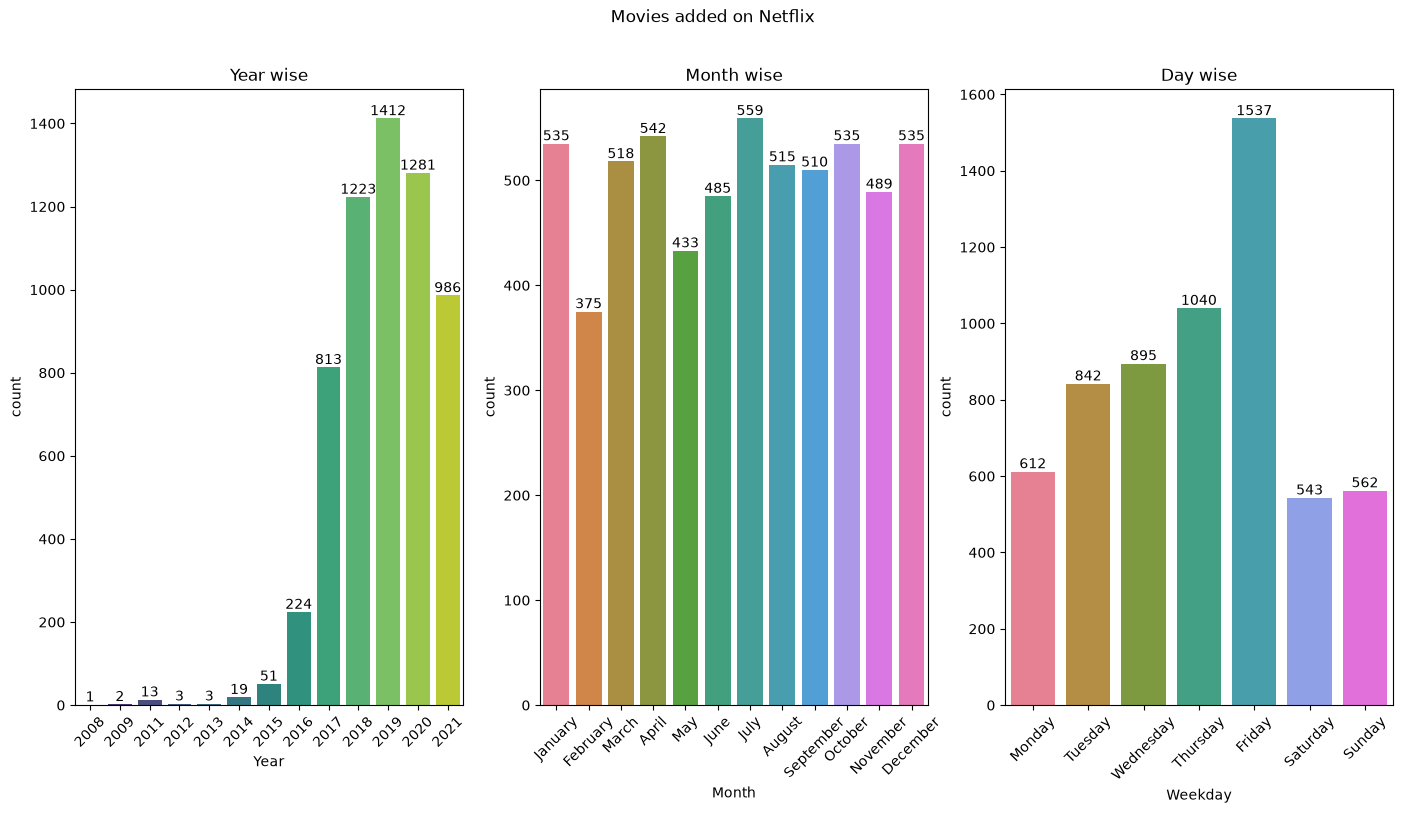

In [70]:
df_movies_temp = df_movies.drop_duplicates(subset=['year', 'title'])
df_movies_temp


mv_year = df_movies_temp['year'].value_counts()
mv_year.sort_index(inplace=True)
mv_year


month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

mv_month = df_movies_temp['month_name'].value_counts().loc[month_order]
mv_month


day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

mv_day = df_movies_temp['weekday'].value_counts().loc[day_order]
mv_day


plt.figure(figsize=(17,8))
plt.suptitle('Movies added on Netflix')


plt.subplot(1,3,1)

label = sns.countplot(
    data=df_movies_temp,
    x='year',
    order=mv_year.index,
    palette='viridis'
)

for i in label.containers:
    label.bar_label(i)

plt.xticks(rotation=45)
plt.xlabel('Year')
plt.title('Year wise')


plt.subplot(1,3,2)

label = sns.countplot(
    data=df_movies_temp,
    x='month_name',
    order=mv_month.index,
    palette='husl'
)

for i in label.containers:
    label.bar_label(i)

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.title('Month wise')


plt.subplot(1,3,3)

label = sns.countplot(
    data=df_movies_temp,
    x='weekday',
    order=mv_day.index,
    palette='husl'
)

for i in label.containers:
    label.bar_label(i)

plt.xticks(rotation=45)
plt.xlabel('Weekday')
plt.title('Day wise')


plt.show()

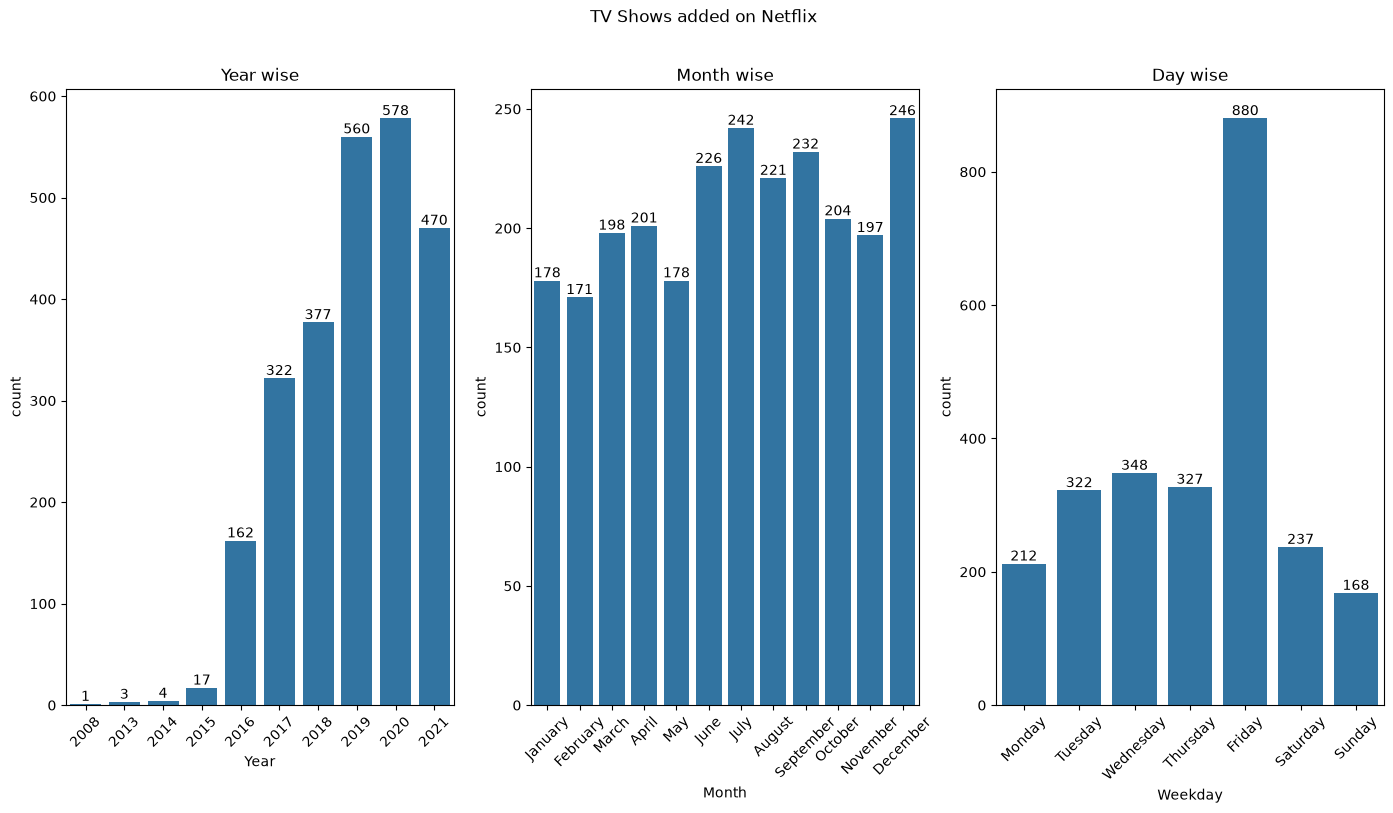

In [67]:
df_tvs_temp = df_tvs.drop_duplicates(subset=['year','title'])

tv_year = df_tvs_temp['year'].value_counts()
tv_year.sort_index(inplace=True)

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
tv_month = df_tvs_temp['month_name'].value_counts().loc[month_order]

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
tv_day = df_tvs_temp['weekday'].value_counts().loc[day_order]


plt.figure(figsize=(17,8))
plt.suptitle('TV Shows added on Netflix')

plt.subplot(1,3,1)
label = sns.countplot(data=df_tvs_temp, x='year', order=tv_year.index)
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Year')
plt.title('Year wise')

plt.subplot(1,3,2)
label = sns.countplot(data=df_tvs_temp, x='month_name', order=tv_month.index)
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.title('Month wise')

plt.subplot(1,3,3)
label = sns.countplot(data=df_tvs_temp, x='weekday', order=tv_day.index)
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Weekday')
plt.title('Day wise')

plt.show()

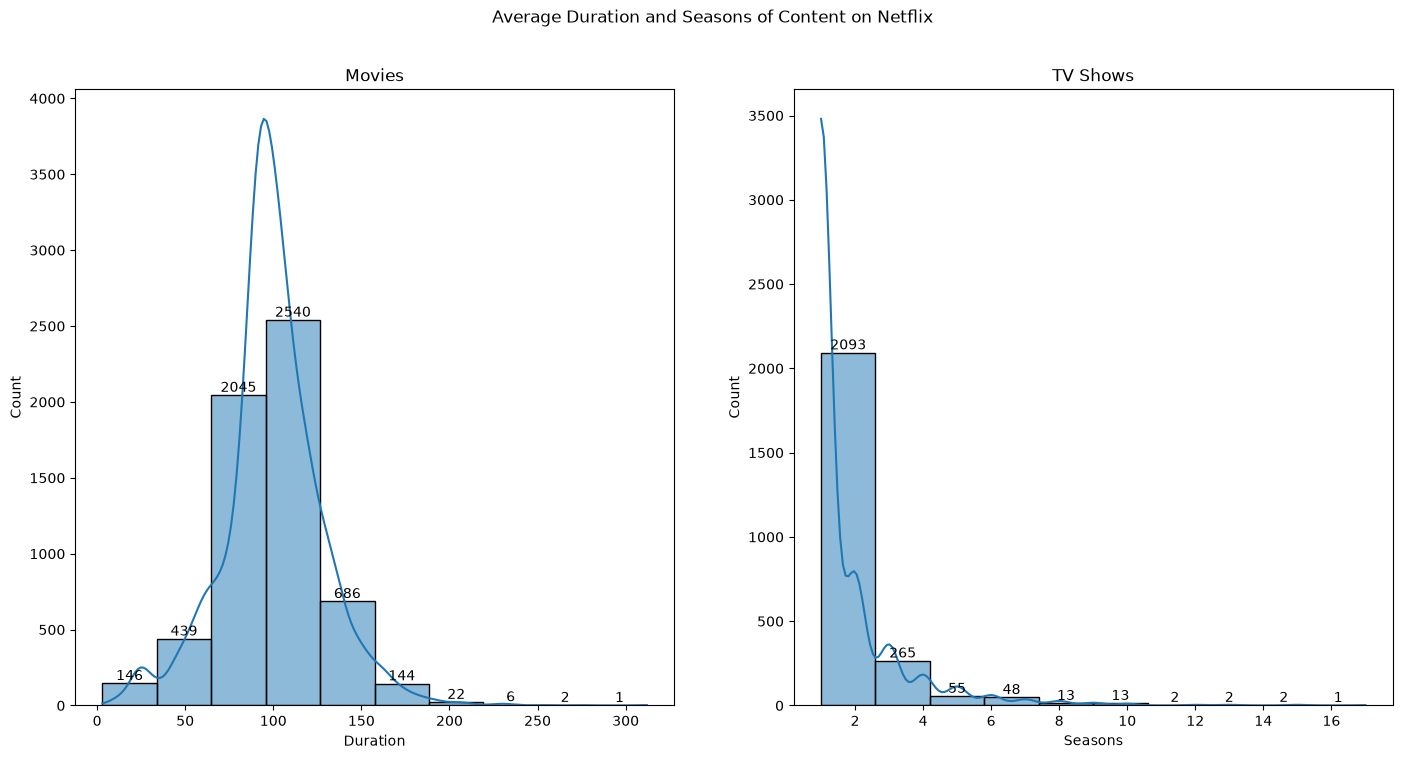

In [68]:
df_movies_temp = df_movies.drop_duplicates(subset=['duration','title'])
df_tvs_temp = df_tvs.drop_duplicates(subset=['seasons','title'])

plt.figure(figsize=(17,8))
plt.suptitle('Average Duration and Seasons of Content on Netflix')

plt.subplot(1,2,1)
label = sns.histplot(df_movies_temp['duration'], bins=10, kde=True)
for i in label.containers:
    label.bar_label(i)
plt.xlabel('Duration')
plt.title('Movies')

plt.subplot(1,2,2)
label = sns.histplot(df_tvs_temp['seasons'], bins=10, kde=True)
for i in label.containers:
    label.bar_label(i)
plt.xlabel('Seasons')
plt.title('TV Shows')

plt.show()

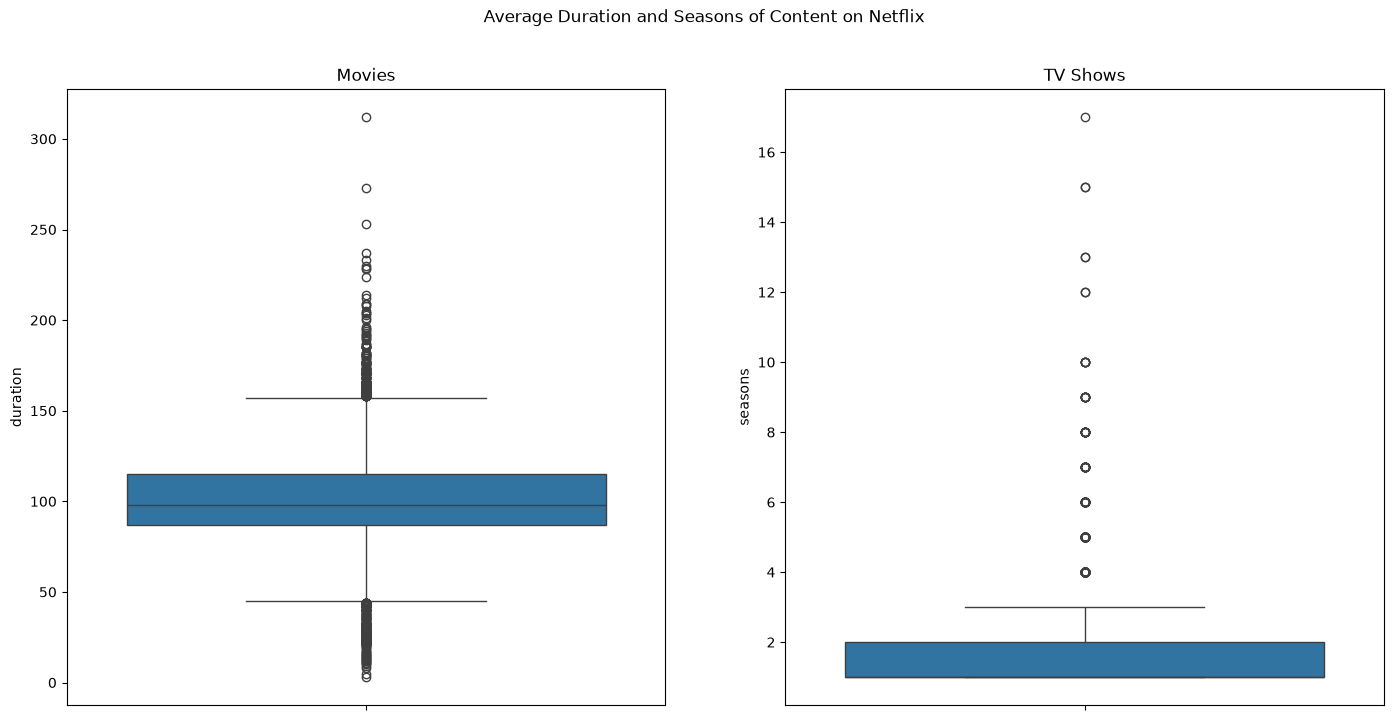

In [71]:
plt.figure(figsize=(17,8))
plt.suptitle('Average Duration and Seasons of Content on Netflix')

plt.subplot(1,2,1)

sns.boxplot(
    y=df_movies_temp['duration']
)

plt.title('Movies')


plt.subplot(1,2,2)

sns.boxplot(
    y=df_tvs_temp['seasons']
)

plt.title('TV Shows')


plt.show()

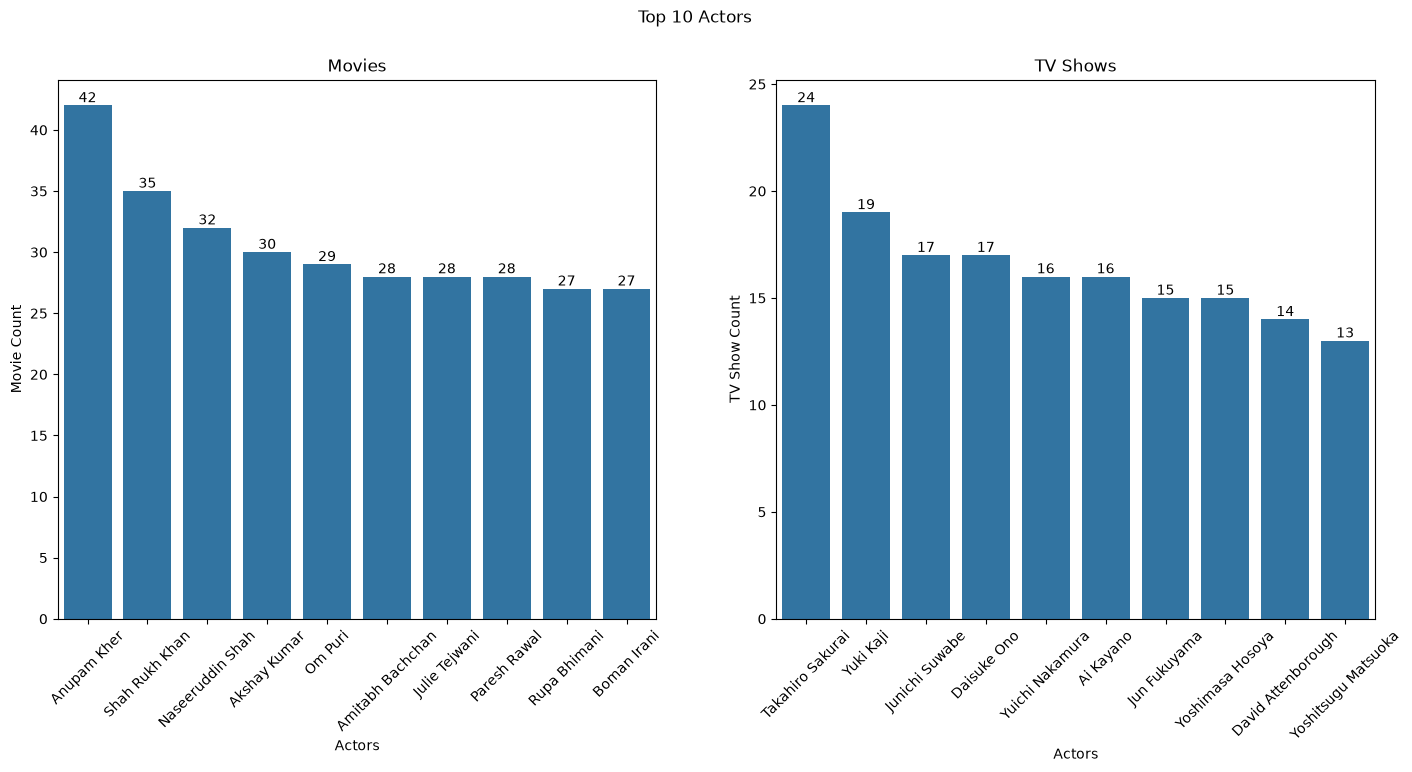

In [73]:
df_movies_temp = df_movies.drop_duplicates(subset=['cast','title'])
df_tvs_temp = df_tvs.drop_duplicates(subset=['cast','title'])

plt.figure(figsize=(17,7))
plt.suptitle('Top 10 Actors')

plt.subplot(1,2,1)
label = sns.countplot(data=df_movies_temp, x='cast', order=df_movies_temp['cast'].value_counts()[1:11].index)
for i in label.containers: label.bar_label(i)
plt.title('Movies')
plt.xticks(rotation=45)
plt.xlabel('Actors')
plt.ylabel('Movie Count')

plt.subplot(1,2,2)
label = sns.countplot(data=df_tvs_temp, x='cast', order=df_tvs_temp['cast'].value_counts()[1:11].index)
for i in label.containers: label.bar_label(i)
plt.title('TV Shows')
plt.xticks(rotation=45)
plt.xlabel('Actors')
plt.ylabel('TV Show Count')

plt.show()

## 📌 Insights from Data Visualization

- **Movies vs TV Shows:** Movies account for **70.74%** of the total content, while TV Shows account for **29.26%**, showing that Netflix has a much larger movie library.

- **Content Across Countries:** The **United States** has the highest amount of Netflix content among the identified countries, with movies contributing much more than TV Shows.

- **Country-wise Content:** India is the second-largest contributor, with a strong dominance of Movies, while countries such as Japan and South Korea have a comparatively higher contribution of TV Shows.

- **Top Directors – Movies:** **Rajiv Chilaka** is the leading director in the movie dataset with **22 movies**, followed by **Ian Suter (21)** and **Raul Campos (19)**.

- **Top Directors – TV Shows:** **Alastair Fothergill** and **Ken Burns** are among the leading TV Show directors, with **3 shows each**.

- **Top Movie Genres:** **International Movies** are the most common movie genre with **2710 titles**, followed by **Dramas (2393)** and **Comedies (1657)**.

- **Top TV Show Genres:** **International TV Shows** dominate with **1300 titles**, followed by **TV Dramas (737)** and **TV Comedies (539)**.

- **Content Classification – Movies:** Among movies, **Adults** category has the highest share at **47.39%**, followed by **Teens (31.72%)** and **Kids (20.89%)**.

- **Content Classification – TV Shows:** Among TV Shows, **Adults** represent **43.87%**, followed by **Kids (28.51%)** and **Teens (27.63%)**.

- **Movies Added by Year:** Netflix added the highest number of movies in **2019**, with **1412 movies**, followed by **2020 (1281)** and **2018 (1223)**.

- **Movies Added by Month:** **July** was the month with the highest number of movie additions, with **559 movies**, while **May** had the lowest with **433 movies**.

- **Movies Added by Weekday:** **Friday** had the highest number of movie additions with **1537**, showing that movie additions were strongly concentrated toward the end of the working week.

- **TV Shows Added by Year:** The highest number of TV Shows were added in **2020**, with **578 shows**, followed by **2019 (560)** and **2021 (470)**.

- **TV Shows Added by Month:** **December** had the highest number of TV Show additions with **246**, followed by **July (242)** and **September (232)**.

- **TV Shows Added by Weekday:** **Friday** had the highest number of TV Show additions with **880**, while **Sunday** had the lowest with **168**.

- **Movie Duration:** Most movies have a duration concentrated around **90–120 minutes**, with the distribution showing that standard-length movies are much more common than very short or very long movies.

- **TV Show Seasons:** Most TV Shows have **1–2 seasons**, with **1-season shows** being the most common. Shows with many seasons are comparatively rare.

- **Movie Duration Outliers:** The boxplot shows several outliers above the normal duration range, indicating that some movies have exceptionally long runtimes.

- **TV Show Season Outliers:** The boxplot shows several TV Shows with more than **3 seasons**, with a few extending to **10+ seasons** and one reaching **17 seasons**.

- **Top Actors – Movies:** **Anupam Kher** appears most frequently among the movie actors with **42 movies**, followed by **Shah Rukh Khan (35)** and **Naseeruddin Shah (32)**.

- **Top Actors – TV Shows:** **Takhiro Sakurai** has the highest appearance count among TV Show actors with **24 shows**, followed by **Yuki Kaji (19)**.

- **Overall Insight:** The analysis shows that Netflix's content library is strongly dominated by **Movies**, with **International Movies, International TV Shows, Dramas and Comedies** being major genres. Content additions increased significantly during **2018–2020**, and **Friday** was the most common day for adding both Movies and TV Shows.